Link Tableau 
https://public.tableau.com/app/profile/christian.ambarita3047/viz/DasboardCoffeeShop/Dashboard1?showOnboarding=true

=================================================

Milestone 2

Nama  : Christian Ambarita

Batch : CODA-RMT-014

=================================================


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


##### PROBLEM STATEMENT

pemilik dari Maven Roastery (Coffee Shop) ingin memahami pola penjualan produk berdasarkan waktu transaksi, kategori produk minuman, dan lokasi toko untuk melakukan peningkatan penjualan toko-tokonya.

##### Key Question

1. Produk apa paling laris?
2. setiap hari dan waktu apa saja paling ramai?
3. Store dengan performa terbaik dimana?
4. Kategori apa yang paling laris?
5. Apakah Harga produk memiliki dampak ke penjualan?
6. Bagaimana distribusi dari harga2 produk yang dijual?

Pertama, akan Mengimport data xlsx ke dataframe

In [2]:
kopi_file=pd.read_excel(r"C:\Users\62822\Downloads\Coffee Shop Sales.xlsx\Coffee Shop Sales.xlsx",sheet_name='Transactions')

didapatkan dari 

https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales/data

In [3]:
kopi_file

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Nilai_terjual
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20
...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75


In [4]:
#melihat informasi isi tiap kolomnya
kopi_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Nilai_terjual     149116 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 13.7+ MB


Selanjutnya, akan dilakukan pengecekan data, apakah ada yang kosong cell nya ataupun duplikat

In [5]:
#Mengecek apakah ada cell di tiap kolom yang kosong
kopi_file.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
Nilai_terjual       0
dtype: int64

In [6]:
#Mengecek apakah ada duplikasi dari tiap baris
kopi_file.duplicated().sum()

np.int64(0)

Maka, aman tidak perlu ada yang di drop

Selanjutnya, akan dilihat apakah data memiliki abnormalitas

In [7]:
#Melihat apakah ada nilai di data kuantitatif yang bersifat abnormal
print(kopi_file[kopi_file['unit_price']<0])
print(kopi_file[kopi_file['transaction_qty']<0])
print(kopi_file[kopi_file['Nilai_terjual']<0])


Empty DataFrame
Columns: [transaction_id, transaction_date, transaction_time, transaction_qty, store_id, store_location, product_id, unit_price, product_category, product_type, product_detail, Nilai_terjual]
Index: []
Empty DataFrame
Columns: [transaction_id, transaction_date, transaction_time, transaction_qty, store_id, store_location, product_id, unit_price, product_category, product_type, product_detail, Nilai_terjual]
Index: []
Empty DataFrame
Columns: [transaction_id, transaction_date, transaction_time, transaction_qty, store_id, store_location, product_id, unit_price, product_category, product_type, product_detail, Nilai_terjual]
Index: []


Maka, dapat dikatakan aman

In [8]:
#melihat apakah ada isi yang mirip nilai dari kolom toko
kopi_file['store_location'].unique()

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

In [9]:
#melihat apakah ada isi yang mirip nilai dari kolom kategori produk
kopi_file['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [10]:
#melihat apakah ada isi yang mirip nilai dari kolom kategori produk
kopi_file['product_type'].unique()

array(['Gourmet brewed coffee', 'Brewed Chai tea', 'Hot chocolate',
       'Drip coffee', 'Scone', 'Barista Espresso', 'Brewed Black tea',
       'Brewed Green tea', 'Brewed herbal tea', 'Biscotti', 'Pastry',
       'Organic brewed coffee', 'Premium brewed coffee', 'Regular syrup',
       'Herbal tea', 'Gourmet Beans', 'Organic Beans', 'Sugar free syrup',
       'Drinking Chocolate', 'Premium Beans', 'Chai tea', 'Green beans',
       'Espresso Beans', 'Green tea', 'Organic Chocolate', 'Housewares',
       'Black tea', 'House blend Beans', 'Clothing'], dtype=object)

Maka, dapat dikatakan semua nilainya tidak ada yang bersifat abnormal

Maka, dapat dikatakan semua isi data sudah clean dan pemrosesan data selanjutnya dapat dilakukan

ANALISIS

Berdasarkan problem statement dan juga pertanyaan, maka pertama kita akan melihat urutan produk apa yang memberikan keutungan terbesar hingga terkecil dan juga jumlah pembelian nya dalam 6 bulan

In [11]:
Penjualan_Produk=kopi_file.groupby('product_type')[['Nilai_terjual','transaction_qty']].sum().sort_values('Nilai_terjual',ascending=False)
Penjualan_Produk.rename(columns={'Nilai_terjual': 'Totalan Keuntungan 6 bulan','transaction_qty': 'jmlh pembelian dlm 6 bulan'},inplace=True)
Penjualan_Produk

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
product_type,,
Barista Espresso,91406.20,24943
Brewed Chai tea,77081.95,26250
Hot chocolate,72416.00,17457
Gourmet brewed coffee,70034.60,25973
Brewed Black tea,47932.00,17462
Brewed herbal tea,47539.50,17328
Premium brewed coffee,38781.15,12431
Organic brewed coffee,37746.50,13012
Scone,36866.12,10465


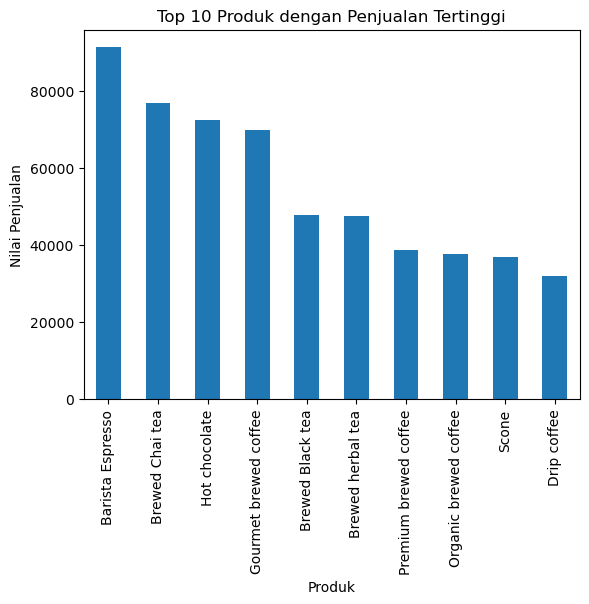

In [12]:
Penjualan_Produk["Totalan Keuntungan 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Produk')
plt.ylabel('Nilai Penjualan')
plt.title("Top 10 Produk dengan Penjualan Tertinggi")
plt.show()

Berdasarkan grafik dapat dilihat walaupun sudah hanya top 10 bahwa produk yang memberikan penjualan tertinggi ada di produk berupa Espresso, Chai Tea, Gourmet brewed Coffee, dan Hot Chocolate yang memberikan penjualan yang signifikan dibandingkan yang lain. Maka, disarankan kemungkinan penjualan lebih fokus ke kopi Espresso, teh Chai, Kopi seduh gourmet , dan coklat panas saja karena jauh lebih signifikan hasil penjualannya dibandingkan produk lainnya. Untuk membuktikan tersebut kita dapat liat juga dari grafik jumlah pembelian produk berikut.

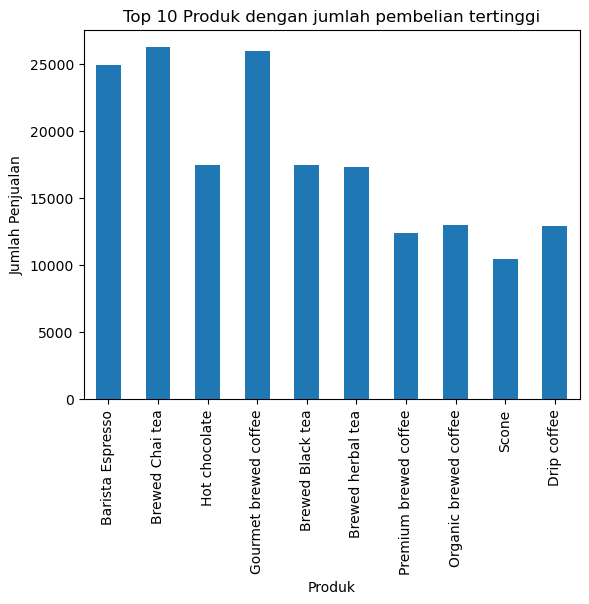

In [13]:
Penjualan_Produk["jmlh pembelian dlm 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Produk')
plt.ylabel('Jumlah Penjualan')
plt.title("Top 10 Produk dengan jumlah pembelian tertinggi")
plt.show()

Dari grafik dapat dilihat bahwa jumlah pembelian produk yang disebutkan sebelumnya berupa Espresso, Chai Tea, Gourmet brewed Coffee, dan Hot Chocolate sering dibeli pelanggan dan dapat juga memberikan pendapatan yang signifikan. hal tersebut dapat dilihat dari jumlah pembelian brewed black tea yang sama dengan hot chocolate tapi hot chocolate masih memberikan pendapatan yang jauh lebih tinggi dari brewed black tea dan produk lainnya yang memiliki jumlah pembelian yang sama.

Selanjutnya, untuk membantu mengkonfirmasi pilihan tersebut kita dapat menambahkan grafik untuk melihat kategori produk yang ramai dibeli

In [14]:
Penjualan_Kat_Produk=kopi_file.groupby('product_category')[['Nilai_terjual','transaction_qty']].sum().sort_values('Nilai_terjual',ascending=False)
Penjualan_Kat_Produk.rename(columns={'Nilai_terjual': 'Totalan Keuntungan 6 bulan','transaction_qty': 'jmlh pembelian dlm 6 bulan'},inplace=True)
Penjualan_Kat_Produk

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
product_category,,
Coffee,269952.45,89250
Tea,196405.95,69737
Bakery,82315.64,23214
Drinking Chocolate,72416.00,17457
Coffee beans,40085.25,1828
Branded,13607.00,776
Loose Tea,11213.60,1210
Flavours,8408.80,10511
Packaged Chocolate,4407.64,487


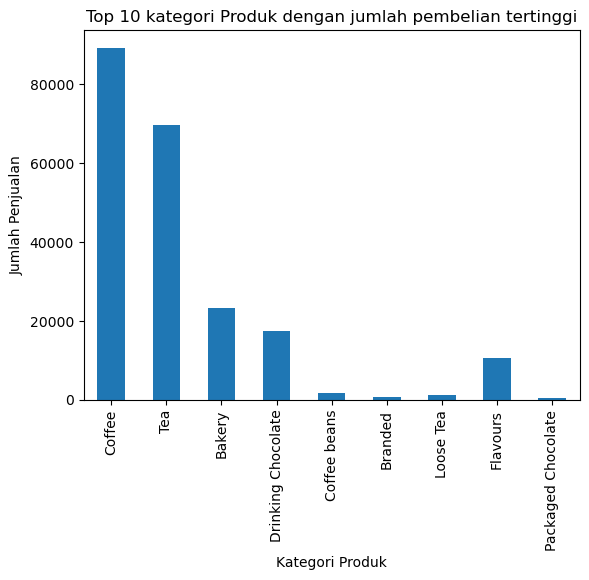

In [15]:
Penjualan_Kat_Produk["jmlh pembelian dlm 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Penjualan')
plt.title("Top 10 kategori Produk dengan jumlah pembelian tertinggi")
plt.show()

Maka, terbukti bahwa memang produk yang dibeli itu secara garis besar nya hanya kopi dan teh. namun, setelahnya ada bakery dan drinking chocolate yang memiliki jumlah pembelian yang hampir sama. Oleh karena itu, kita lihat lagi apakah bakery dapat dijadikan tambahan produk yang difokuskan selain dari drinking chocolate (Hot Chocolate) berdasarkan penjualan keduanya dibandingkan.

In [16]:
#product type berdasarkan category 'Bakery'
kopi_file[kopi_file["product_category"] == "Bakery"]["product_type"].unique()

array(['Scone', 'Biscotti', 'Pastry'], dtype=object)

In [17]:
#product type berdasarkan category 'Drinking Chocolate'
kopi_file[kopi_file["product_category"] == "Drinking Chocolate"]["product_type"].unique()

array(['Hot chocolate'], dtype=object)

Kemudian, kita akan liat perbandingannya

In [18]:
perbandingan_4_produ= Penjualan_Produk.loc[["Hot chocolate", "Scone", "Biscotti", "Pastry"]]
perbandingan_4_produ

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
product_type,,
Hot chocolate,72416.00,17457
Scone,36866.12,10465
Biscotti,19793.53,5788
Pastry,25655.99,6961


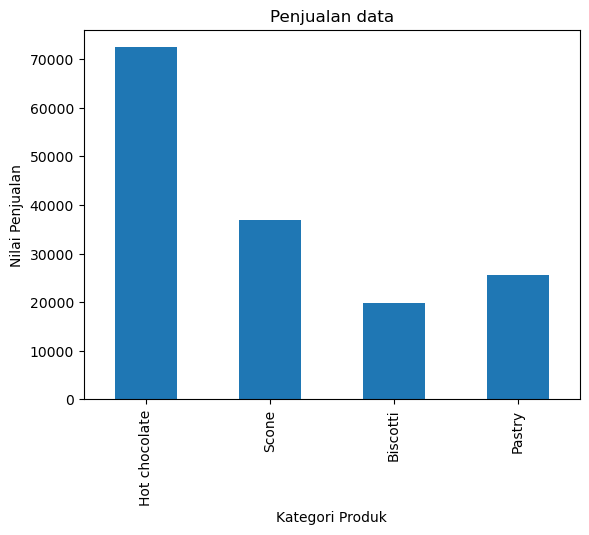

In [19]:
perbandingan_4_produ["Totalan Keuntungan 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Kategori Produk')
plt.ylabel('Nilai Penjualan')
plt.title("Penjualan data")
plt.show()

Dikarenakan drinking chocolate itu hanya hot chocolate dan memiliki nilai penjualan yang lebih signifikan secara jauh dibandingkan produk bakery, maka lebih baik kita fokus ke hot chocolate daripada bakery karena dengan hanya 1 produk yaitu hot chcolate kita mendapatkan penjualan yang lebih tinggi daripada 3 produk.

Selanjutnya, setelah melihat produk dan kategorinya yang menjadi pilihan terbaik, kita akan melihat pada hari apa saja produk memberikan penjualan yang signifikan

In [20]:
#menambhakan kolom nama hari
kopi_file["Day_name"] = kopi_file["transaction_date"].dt.day_name()
kopi_file

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Nilai_terjual,Day_name
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,Sunday
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,Sunday
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,Sunday
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,Friday
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,Friday
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,Friday
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,Friday


In [21]:
Hari_Penjualan=kopi_file.groupby('Day_name')[['Nilai_terjual','transaction_qty']].sum().sort_values('Nilai_terjual',ascending=False)
Hari_Penjualan.rename(columns={'Nilai_terjual': 'Totalan Keuntungan 6 bulan','transaction_qty': 'jmlh pembelian dlm 6 bulan'},inplace=True)
Hari_Penjualan

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
Day_name,,
Monday,101677.28,31231
Friday,101373.00,31207
Thursday,100767.78,31162
Wednesday,100313.54,30625
Tuesday,99455.94,30449
Sunday,98330.31,30182
Saturday,96894.48,29614


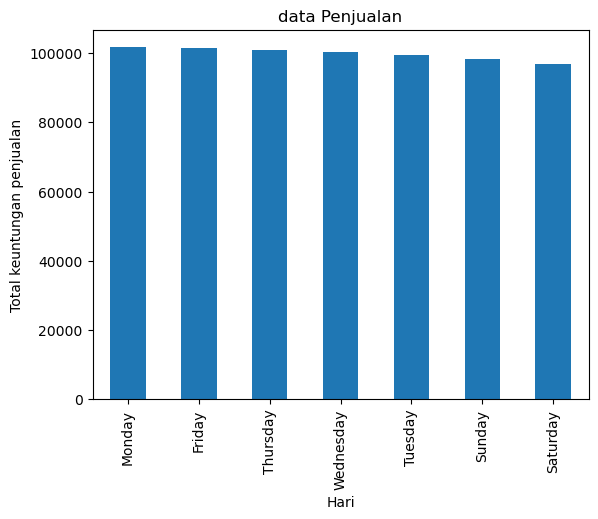

In [22]:
Hari_Penjualan["Totalan Keuntungan 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Hari')
plt.ylabel('Total keuntungan penjualan')
plt.title("data Penjualan")
plt.show()

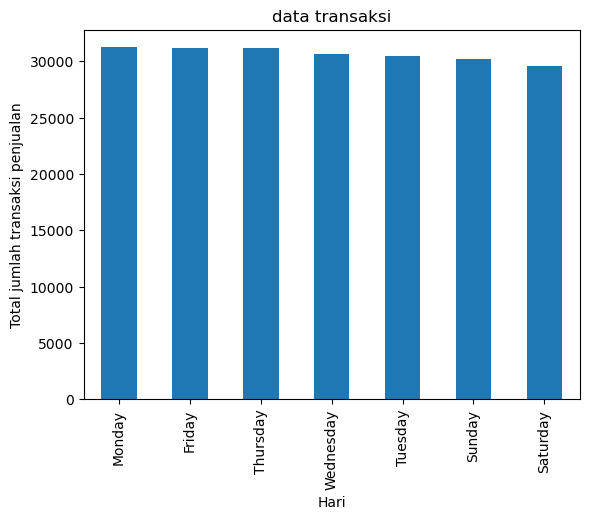

In [23]:
Hari_Penjualan["jmlh pembelian dlm 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Hari')
plt.ylabel('Total jumlah transaksi penjualan')
plt.title("data transaksi")
plt.show()

Maka, dapat dikatakan bahwa tidak ada pengaruh dari hari apa toko buka terhadap jumlah penjualan dan besarnya pendapatan yang didapatkan, oleh karena itu mungkin kita dapat bisa liat ke variabel lain yaitu jam penjualan.

In [24]:
#Menambahkan kolom yang menampilkan jam
kopi_file['Nilai_jam']=kopi_file["transaction_time"].astype(str).str[:2]
kopi_file

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Nilai_terjual,Day_name,Nilai_jam
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,Sunday,07
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,07
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,Sunday,07
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,Sunday,07
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,Friday,20
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,Friday,20
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,Friday,20
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,Friday,20


In [25]:
jam_Data=kopi_file.groupby('Nilai_jam')[['Nilai_terjual','transaction_qty']].sum().sort_values('Nilai_terjual',ascending=False)
jam_Data.rename(columns={'Nilai_terjual': 'Totalan Keuntungan 6 bulan','transaction_qty': 'jmlh pembelian dlm 6 bulan'},inplace=True)
jam_Data

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
Nilai_jam,,
10,88673.39,26713
09,85169.53,25370
08,82699.87,25197
07,63526.47,19449
11,46319.14,14035
15,41733.10,12923
14,41304.74,12907
16,41122.75,12881
13,40367.45,12439


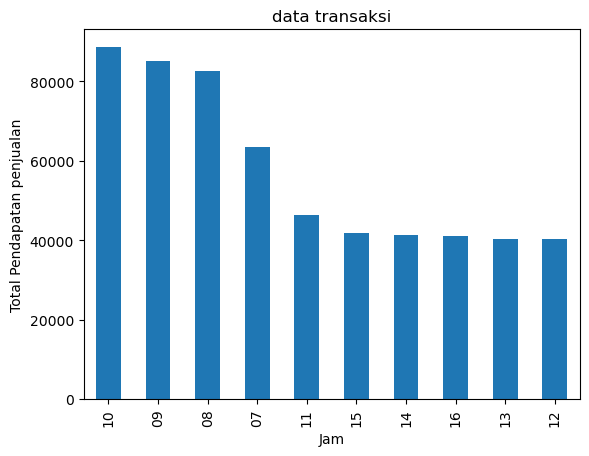

In [26]:
jam_Data["Totalan Keuntungan 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Jam')
plt.ylabel('Total Pendapatan penjualan')
plt.title("data transaksi")
plt.show()

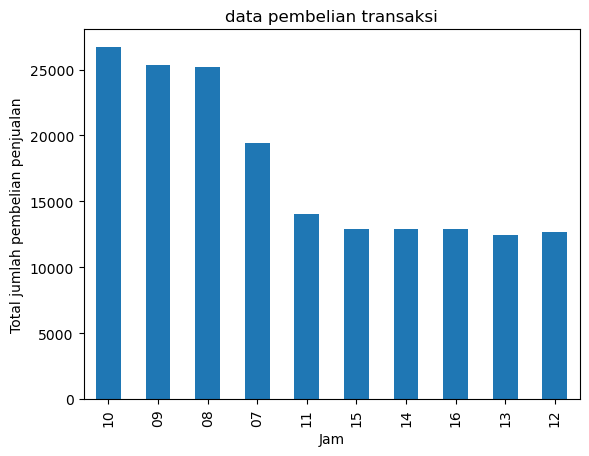

In [27]:
jam_Data["jmlh pembelian dlm 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Jam')
plt.ylabel('Total jumlah pembelian penjualan')
plt.title("data pembelian transaksi")
plt.show()

Didapatkan bahwa toko sangatlah aktif pembelian pada saat pagi menuju siang (8-10). dimana, berarti kita dapat lebih mengatur jam kerja yang lebih baik dan juga menentukan jam istrahat yang strategis.

Setelah kita menentukan waktu dan produk apa yang berperan signifikan terhadap penjualan. maka, selanjutnya kita akan melihat apakah ada toko yang berperan lebih signifikan daripada toko lainnya.

In [29]:
Toko_Data=kopi_file.groupby('store_location')[['Nilai_terjual','transaction_qty']].sum().sort_values('Nilai_terjual',ascending=False)
Toko_Data.rename(columns={'Nilai_terjual': 'Totalan Keuntungan 6 bulan','transaction_qty': 'jmlh pembelian dlm 6 bulan'},inplace=True)
Toko_Data

,Totalan Keuntungan 6 bulan,jmlh pembelian dlm 6 bulan
store_location,,
Hell's Kitchen,236511.17,71737
Astoria,232243.91,70991
Lower Manhattan,230057.25,71742


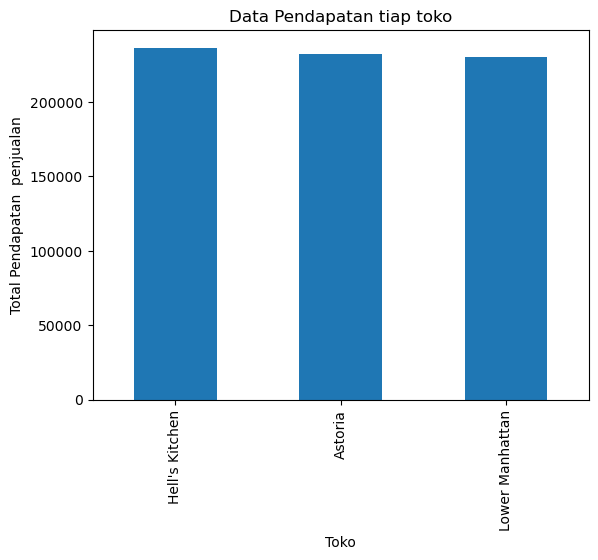

In [32]:
Toko_Data["Totalan Keuntungan 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Toko')
plt.ylabel('Total Pendapatan  penjualan')
plt.title("Data Pendapatan tiap toko")
plt.show()

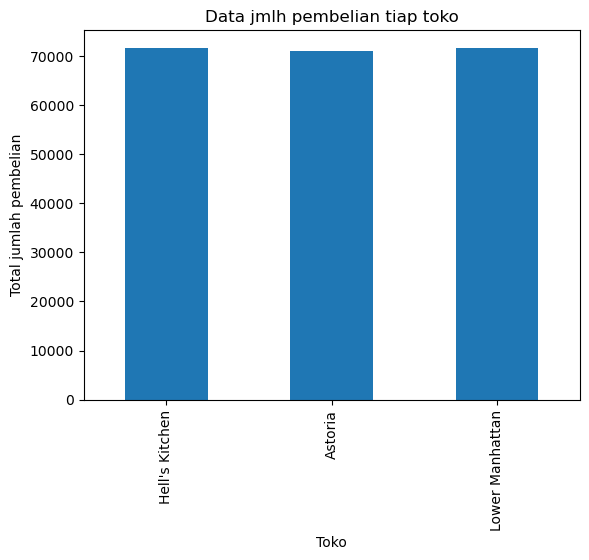

In [33]:
Toko_Data["jmlh pembelian dlm 6 bulan"].head(10).plot(kind="bar")
plt.xlabel('Toko')
plt.ylabel('Total jumlah pembelian')
plt.title("Data jmlh pembelian tiap toko")
plt.show()

Maka, dapat disimpulkan bahwa ketiga toko memiliki jumlah penjualan dan pendapatan yang hampir sama dan tidak ada yang memiliki penjualan signifikan dibandingkan lainnya. maka, tidak ada toko yang perlu yang perlu di beri perhatian khusus.

Setelah kita tahu bahwa hanya beberapa produk saja yang memiliki penjualan signifikan dibandingkan produk lainnya. maka, kita akan mencari tahu apakah harga produk memiliki dampak ke penjualan.

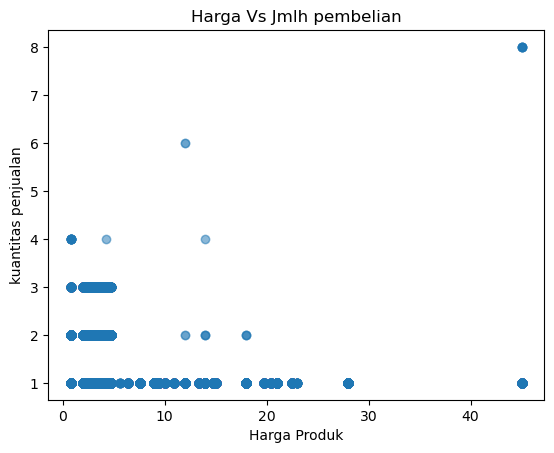

In [35]:
plt.scatter(kopi_file['unit_price'],kopi_file['transaction_qty'] ,alpha=0.3)
plt.xlabel('Harga Produk')
plt.ylabel('kuantitas penjualan')

plt.title('Harga Vs Jmlh pembelian')

plt.show()

terjadi penumpukan dari kuantitas pembelian 1 dan 2, dimana berarti pelanggan umumnya hanya membeli 1 item per transaksi. kemudian, dapat dilihat juga bahwa tidak ada korelasi dari harga terhadap jumlah pembelian per transaksi yang berarti hubungan harga dan kuantitas per transaksi itu lemah. Namun, scatter tersebut tidak dapat menyimpulkan bahwa harga tidak berpengaruh terhadap penjualan secara keseluruhan. Maka, kita akan membuat versi untuk penjualan keseluruhan nya

In [ ]:
# membuat df rata2 harga per produk, totalan transasksi per produk, dan totalan pendapatan per produk
per_produk = kopi_file.groupby("product_type").agg({"unit_price": "mean","transaction_qty": "sum","Nilai_terjual": "sum"})
per_produk 

,unit_price,transaction_qty,Nilai_terjual
product_type,,,
Barista Espresso,3.655200,24943,91406.20
Biscotti,3.419503,5788,19793.53
Black tea,8.950000,303,2711.85
Brewed Black tea,2.744670,17462,47932.00
Brewed Chai tea,2.936993,26250,77081.95
Brewed Green tea,2.742462,8697,23852.50
Brewed herbal tea,2.744731,17328,47539.50
Chai tea,9.709368,443,4301.25
Clothing,27.886878,221,6163.00


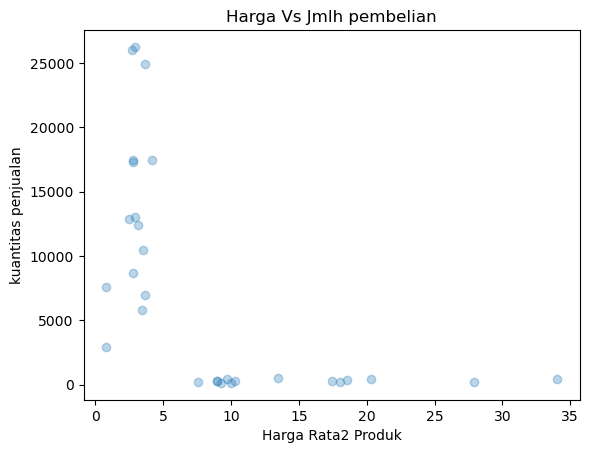

In [40]:
plt.scatter(per_produk['unit_price'],per_produk['transaction_qty'] ,alpha=0.3)
plt.xlabel('Harga Rata2 Produk')
plt.ylabel('kuantitas penjualan')

plt.title('Harga Vs Jmlh pembelian')

plt.show()

Didapatkan bahwa jika dilihat secara keseluruhan bahwa item produk yang memiliki harga rata2 <=$5 memberikan kontribusi penjualan yang jauh diatas daripada item yang memiliki harga >$5. selanjutnya, kita dapat menggunakan korelasi untuk melihat lebih pasti apakah ada korelasi dengan metode pearson harga produk terhadap jumlah penjualan. Berikut hipotesisnya

H0 : tidak ada korelasi harga dan jumlah pembelian

H1 : ada korelasi harga dan jumlah pembelian

a  : 0,05


In [45]:
pearsonr(per_produk["unit_price"],per_produk["transaction_qty"])

PearsonRResult(statistic=np.float64(-0.5867932490454768), pvalue=np.float64(0.0008202556572698709))

dari uji korelasi pearson didapatkan bahwa tolak H0 yang berarti ada korelasi antar harga dengan jumlah pembelian secara keseluruhan yang akan dilihat dari nilai korelasi. Dari nilai korelasi -0,59 menunjukkan bahwa produk dengan harga lebih tinggi memberikan penjualan yang jauh lebih rendah (Berbanding terbalik).

Terakhir, karena kita tau penjualan yang berperan signifikan terhadap penjualan ada pada produk yang memiliki harga rendah seperti espresso, chai tea, dan hot chcolate yang memiliki harga rata2 dibawah $5. maka, kita akan melihat apakah distribusi harga dari keseluruhan menu produk memiliki harga yang rendah atau memiliki outlier yang jauh dari produk yang memiliki harga rendah tadi agar disesuaikan lagi.


In [ ]:
#informasi mengenai kolom harga2 produk
kopi_file["unit_price"].describe()


count    149116.000000
mean          3.382219
std           2.658723
min           0.800000
25%           2.500000
50%           3.000000
75%           3.750000
max          45.000000
Name: unit_price, dtype: float64

In [ ]:
#mengecek outlier pake IQR
Q1 = kopi_file["unit_price"].quantile(0.25)
Q3 = kopi_file["unit_price"].quantile(0.75)
IQR = Q3 - Q1
print('IQR=',IQR)
outlierrr = kopi_file[kopi_file["unit_price"] > Q3 + 1.5*IQR]

outlierrr["unit_price"].unique()

IQR= 1.25


array([ 8.95, 21.  , 28.  ,  6.4 , 19.75, 12.  , 18.  ,  9.5 , 10.  ,
       20.45,  9.25, 22.5 , 14.75,  7.6 , 14.  , 10.95, 13.33, 15.  ,
        5.63, 45.  , 23.  ])

In [ ]:
persen_outlier= len(outlierrr["unit_price"])/len(kopi_file["unit_price"])*100
print('Persentase Outlier : ', persen_outlier,'%')

Persentase Outlier :  2.824646583867593 %


Maka, IQR menunjukkan bahwa hanya sekitar 2.82% data harga yang termasuk outlier. Nilai outlier tersebut berasal dari produk premium seperti coffee beans dan produk premium lainnya. maka, dapat dikatakan bahwa harga2 produk sudah sesuai mengikuti strategi dimana kita mementingkan penjualan produk mass (banyak) daripada penjualan barang premium.

In [60]:
kopi_file

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Nilai_terjual,Day_name,Nilai_jam
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,Sunday,07
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,07
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,Sunday,07
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,Sunday,07
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,Friday,20
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,Friday,20
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,Friday,20
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,Friday,20


In [65]:
kopi_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Nilai_terjual     149116 non-null  float64       
 12  Day_name          149116 non-null  object        
 13  Nilai_jam         149116 non-null  object        
dtypes: d

ACTIONABLE ACTION Dan KESIMPULAN

Maka, saya sarankan pemilik toko kopi ini untuk fokus ke produk yang memiliki harga rendah (dibawah $5) dengan contoh produk yang bisa menjadi pilihan prioritas adalah Espresso, Chai Tea, dan Hot Chocolate. Selanjutnya, pemilik toko dapat juga mengatur jam kerja dan istrahat agar bisa fokus ke jam kerja di jam pagi menuju siang (jam 8-10). Terakhir, Pemilik toko juga dapat dapat mengatur agar produk yang dijual itu targetnya ke penjualan produk secara banyak (Mass Selling) dan lebih menjauhi penjualan produk-produk premium atau kalo bisa kuantitas produk premium yang dijual itu dikurangi.